In [1]:
import numpy as np  # linear algebra
import pandas as pd  # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import warnings

warnings.filterwarnings(
    "ignore"
)  # suppress non‑critical warnings that add I/O overhead




In [2]:
df_train = pd.read_csv(r"/kaggle/input/cassava-leaf-disease-classification/train.csv")
df_train.head()




,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3


In [3]:
import json

with open(
    r"/kaggle/input/cassava-leaf-disease-classification/label_num_to_disease_map.json"
) as json_file:
    label_map = json.load(json_file)
label_map = {int(k): v for k, v in label_map.items()}
label_map




{0: 'Cassava Bacterial Blight (CBB)',
 1: 'Cassava Brown Streak Disease (CBSD)',
 2: 'Cassava Green Mottle (CGM)',
 3: 'Cassava Mosaic Disease (CMD)',
 4: 'Healthy'}

In [4]:
df_train["disease"] = df_train["label"].map(label_map)
df_train




,image_id,label,disease
0,1000015157.jpg,0,Cassava Bacterial Blight (CBB)
1,1000201771.jpg,3,Cassava Mosaic Disease (CMD)
2,100042118.jpg,1,Cassava Brown Streak Disease (CBSD)
3,1000723321.jpg,1,Cassava Brown Streak Disease (CBSD)
4,1000812911.jpg,3,Cassava Mosaic Disease (CMD)
...,...,...,...
18716,999068805.jpg,3,Cassava Mosaic Disease (CMD)
18717,999329392.jpg,3,Cassava Mosaic Disease (CMD)
18718,999474432.jpg,1,Cassava Brown Streak Disease (CBSD)
18719,999616605.jpg,4,Healthy


In [5]:
import glob

train_path = glob.glob(
    r"/kaggle/input/cassava-leaf-disease-classification/train_images/*.jpg"
)
train_path.sort()
print(len(train_path))




18721


In [6]:
df_train["path"] = train_path
df_train




,image_id,label,disease,path
0,1000015157.jpg,0,Cassava Bacterial Blight (CBB),/kaggle/input/cassava-leaf-disease-classificat...
1,1000201771.jpg,3,Cassava Mosaic Disease (CMD),/kaggle/input/cassava-leaf-disease-classificat...
2,100042118.jpg,1,Cassava Brown Streak Disease (CBSD),/kaggle/input/cassava-leaf-disease-classificat...
3,1000723321.jpg,1,Cassava Brown Streak Disease (CBSD),/kaggle/input/cassava-leaf-disease-classificat...
4,1000812911.jpg,3,Cassava Mosaic Disease (CMD),/kaggle/input/cassava-leaf-disease-classificat...
...,...,...,...,...
18716,999068805.jpg,3,Cassava Mosaic Disease (CMD),/kaggle/input/cassava-leaf-disease-classificat...
18717,999329392.jpg,3,Cassava Mosaic Disease (CMD),/kaggle/input/cassava-leaf-disease-classificat...
18718,999474432.jpg,1,Cassava Brown Streak Disease (CBSD),/kaggle/input/cassava-leaf-disease-classificat...
18719,999616605.jpg,4,Healthy,/kaggle/input/cassava-leaf-disease-classificat...


<Axes: xlabel='disease'>

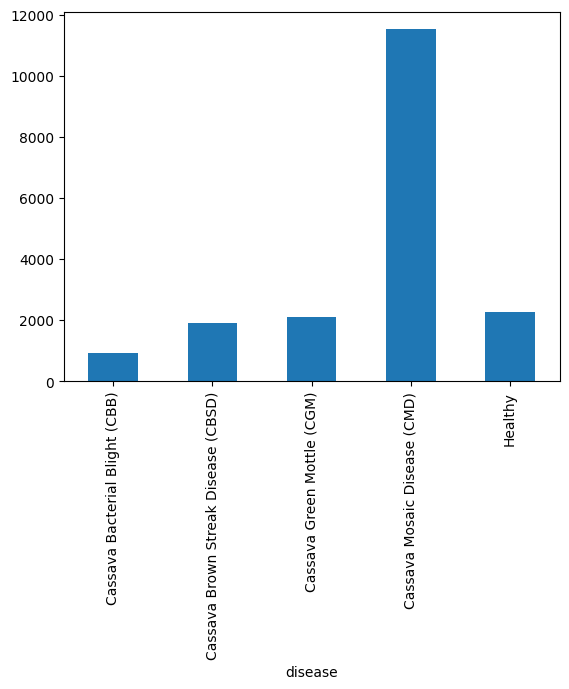

In [7]:
df_train.groupby(["disease"]).size().plot(kind="bar")




In [8]:
import matplotlib.pyplot as plt
from PIL import Image




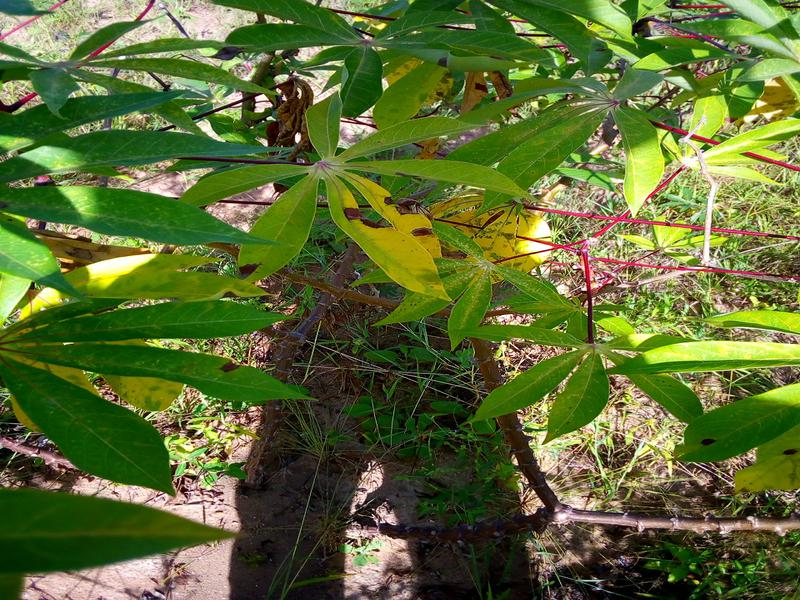

In [9]:
img = Image.open(df_train.path.iloc[0])
img




In [10]:
img.size




(800, 600)

In [11]:
from tqdm.notebook import tqdm  # to monitor progress

np.random.seed(42)  # to get reproducible results




In [12]:
df_samp = df_train.sample(500, random_state=42).reset_index(drop=True)
df_samp.groupby(by="disease").count()




,image_id,label,path
disease,,,
Cassava Bacterial Blight (CBB),25,25,25
Cassava Brown Streak Disease (CBSD),52,52,52
Cassava Green Mottle (CGM),63,63,63
Cassava Mosaic Disease (CMD),307,307,307
Healthy,53,53,53


In [13]:
from sklearn.utils import shuffle

df_samp = shuffle(df_samp).reset_index(drop=True)  # shuffling the dataframe




In [14]:
from sklearn.model_selection import train_test_split

X = df_samp.drop(columns=["label"])
y = df_samp["label"]
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

print(X_train.shape)
print(len(y_train))
print(X_valid.shape)
print(len(y_valid))




(350, 3)
350
(150, 3)
150


In [15]:
# Parallelized image resizing for training and validation sets
import concurrent.futures

compressed_size = (200, 150)  # (width, height)
height, width = compressed_size[1], compressed_size[0]
resample_method = Image.Resampling.LANCZOS


def _process_path(path):
    img = Image.open(path).convert("RGB").resize(compressed_size, resample_method)
    return np.asarray(img, dtype=np.uint8).ravel()


# Train set
num_train = len(X_train)
train_list = list(X_train["path"])
with concurrent.futures.ThreadPoolExecutor(
    max_workers=min(8, os.cpu_count())
) as executor:
    train_array = np.stack(
        list(
            tqdm(
                executor.map(_process_path, train_list),
                total=num_train,
                desc="Resize train",
            )
        )
    )

# Validation set
num_valid = len(X_valid)
valid_list = list(X_valid["path"])
with concurrent.futures.ThreadPoolExecutor(
    max_workers=min(8, os.cpu_count())
) as executor:
    valid_array = np.stack(
        list(
            tqdm(
                executor.map(_process_path, valid_list),
                total=num_valid,
                desc="Resize valid",
            )
        )
    )

print(train_array.shape)
print(valid_array.shape)




Resize train:   0%|          | 0/350 [00:00<?, ?it/s]

Resize valid:   0%|          | 0/150 [00:00<?, ?it/s]

(350, 90000)
(150, 90000)


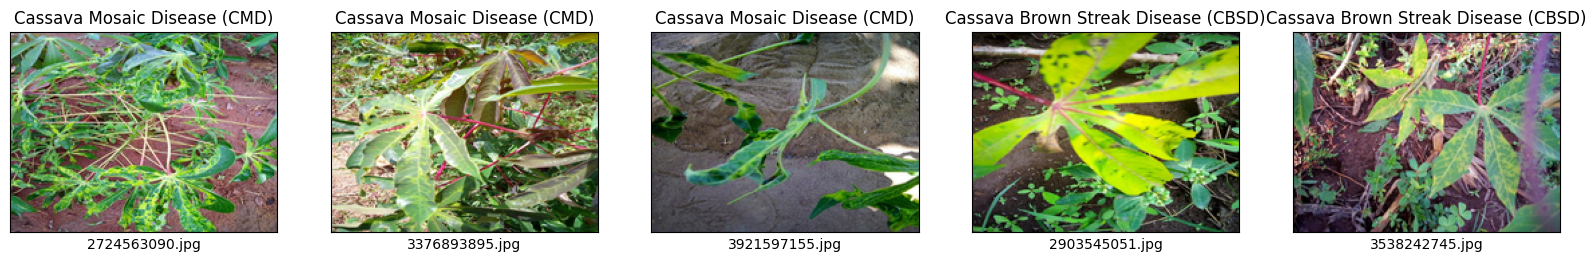

In [16]:
plt.figure(figsize=(20, 12))
for i, img in enumerate(train_array[:5].reshape(-1, height, width, 3)):
    plt.subplot(1, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(img)
    plt.title(X_train["disease"].iloc[i])
    plt.xlabel(X_train["image_id"].iloc[i])
plt.show()




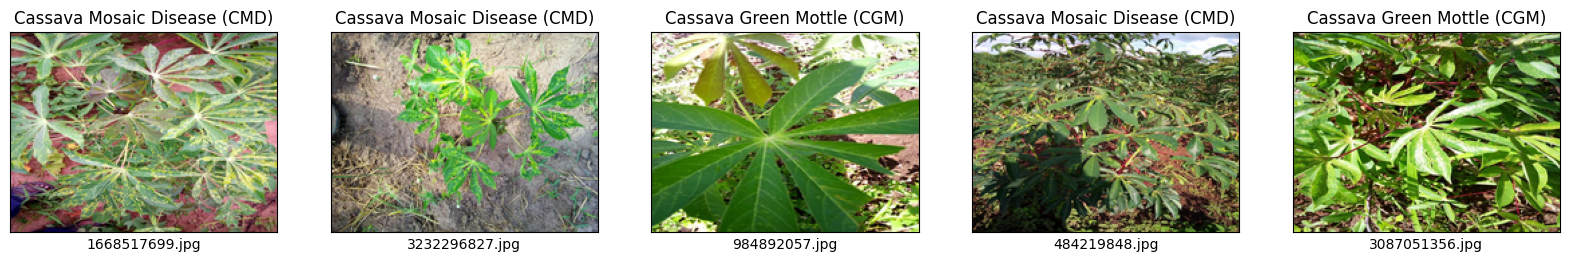

In [17]:
plt.figure(figsize=(20, 12))
for i, img in enumerate(valid_array[:5].reshape(-1, height, width, 3)):
    plt.subplot(1, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(img)
    plt.title(X_valid["disease"].iloc[i])
    plt.xlabel(X_valid["image_id"].iloc[i])
plt.show()




In [18]:
print(f"Length of the training array is {len(train_array)}")
print(f"Shape of the training array is {train_array.shape}")
print(f"Shape of each training image array is {train_array[0].shape}")




Length of the training array is 350
Shape of the training array is (350, 90000)
Shape of each training image array is (90000,)


In [19]:
print("Training array already flattened; shape unchanged.")




Training array already flattened; shape unchanged.


In [20]:
print("Validation array already flattened; shape unchanged.")




Validation array already flattened; shape unchanged.


In [21]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight="balanced", verbose=0, n_jobs=1, max_iter=1000)




In [22]:
lr.fit(train_array, y_train)




LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=1)

In [23]:
preds = lr.predict(valid_array)




In [24]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score




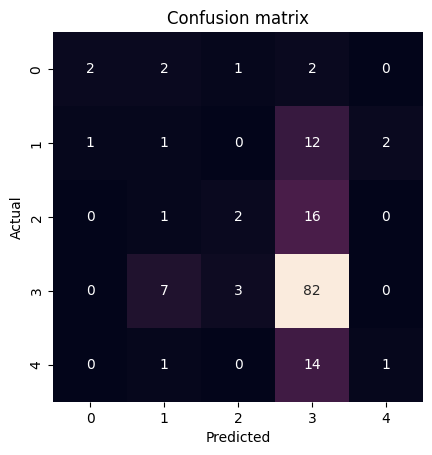

In [25]:
import seaborn as sns

label = sorted(y_valid.unique())
sns.heatmap(
    confusion_matrix(y_valid, preds),
    annot=True,
    square=True,
    fmt="g",
    xticklabels=label,
    yticklabels=label,
    cbar=False,
)
plt.title("Confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()




In [26]:
print(classification_report(y_valid, preds))




              precision    recall  f1-score   support

           0       0.67      0.29      0.40         7
           1       0.08      0.06      0.07        16
           2       0.33      0.11      0.16        19
           3       0.65      0.89      0.75        92
           4       0.33      0.06      0.11        16

    accuracy                           0.59       150
   macro avg       0.41      0.28      0.30       150
weighted avg       0.52      0.59      0.52       150



In [27]:
test_path = glob.glob(
    r"/kaggle/input/cassava-leaf-disease-classification/test_images/*.jpg"
)
test_path.sort()
print(len(test_path))
test_path




2676


['/kaggle/input/cassava-leaf-disease-classification/test_images/1234294272.jpg',
 '/kaggle/input/cassava-leaf-disease-classification/test_images/1234332763.jpg',
 '/kaggle/input/cassava-leaf-disease-classification/test_images/1234375577.jpg',
 '/kaggle/input/cassava-leaf-disease-classification/test_images/1234555380.jpg',
 '/kaggle/input/cassava-leaf-disease-classification/test_images/1234571117.jpg',
 '/kaggle/input/cassava-leaf-disease-classification/test_images/123464878.jpg',
 '/kaggle/input/cassava-leaf-disease-classification/test_images/1234924764.jpg',
 '/kaggle/input/cassava-leaf-disease-classification/test_images/1234931385.jpg',
 '/kaggle/input/cassava-leaf-disease-classification/test_images/1235142158.jpg',
 '/kaggle/input/cassava-leaf-disease-classification/test_images/12351712.jpg',
 '/kaggle/input/cassava-leaf-disease-classification/test_images/1235188286.jpg',
 '/kaggle/input/cassava-leaf-disease-classification/test_images/1236036550.jpg',
 '/kaggle/input/cassava-leaf-di

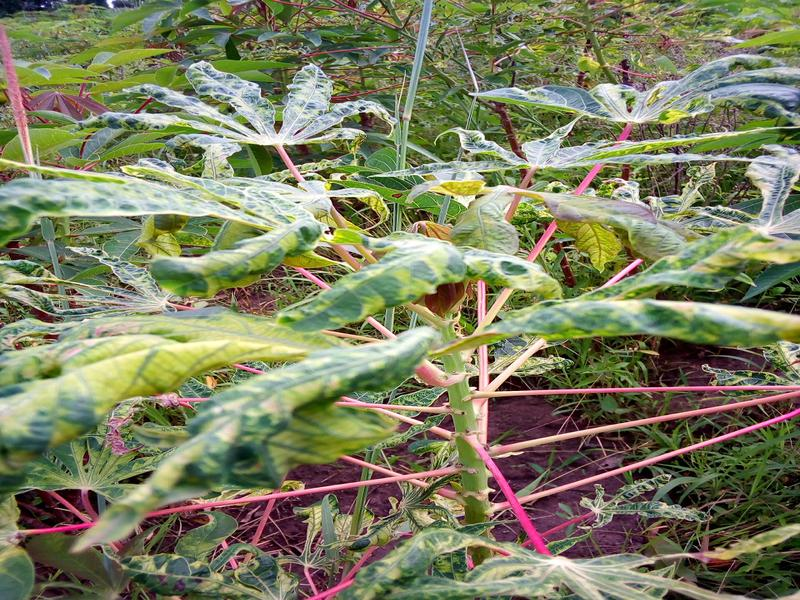

In [28]:
Image.open(test_path[0])




In [29]:
# Parallelized resizing for the full test set
num_test = len(test_path)


def _process_test_path(path):
    img = Image.open(path).convert("RGB").resize(compressed_size, resample_method)
    return np.asarray(img, dtype=np.uint8).ravel()


with concurrent.futures.ThreadPoolExecutor(
    max_workers=min(8, os.cpu_count())
) as executor:
    test_array = np.stack(
        list(
            tqdm(
                executor.map(_process_test_path, test_path),
                total=num_test,
                desc="Resize test",
            )
        )
    )

print(test_array.shape)




Resize test:   0%|          | 0/2676 [00:00<?, ?it/s]

(2676, 90000)


In [30]:
submission = lr.predict(test_array)
submission




array([3, 1, 3, ..., 3, 1, 3])

In [31]:
submission_df = pd.DataFrame(
    {"image_id": [os.path.basename(path) for path in test_path], "label": submission}
)
submission_df




,image_id,label
0,1234294272.jpg,3
1,1234332763.jpg,1
2,1234375577.jpg,3
3,1234555380.jpg,3
4,1234571117.jpg,3
...,...,...
2671,2656351084.jpg,3
2672,2656378111.jpg,3
2673,2656781269.jpg,3
2674,2656964450.jpg,1


In [32]:
submission_df.to_csv("/kaggle/working/submission.csv", index=False)